In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import *
from analysis.aggregations import *
from analysis.plots import *

## Jupyter notes

## A single run

In [2]:
#FOLDER = "04-03-26--14_34_00/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

# FOLDER = "26-02-26--11_04_41/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

# FOLDER = "05-03-26--14_56_45/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

FOLDER = "11-03-26--09_59_00/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"


data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
if FOLDER:
    data_dir = data_dir / FOLDER

run = load_run(data_dir)

# Normalize units: wei → ETH, ratio → %
run = normalize_run(run)
res = merge_runs([run])

### Aggregate global accuracy by round

In [3]:
# data = res['users']
# aggregated = agg_global_accuracy_by_round(data)
#
# aggregated

## Multiple runs

In [4]:
# FOLDER = "26-02-26--11_04_41/"
#
# data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
# if FOLDER:
#     data_dir = data_dir / FOLDER
#
# runs = load_runs(data_dir)
#
# # Normalize units: wei → ETH, ratio → %
# runs = normalize_runs(runs)
# res = merge_runs(runs)

## Plots

## Plot: GRS by user

In [16]:
data = res['users']

# data[['grs', 'user_id', 'round']]

vals = grs_by_user(data)

# fig = plot_grs_by_user(vals)

# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

data = res['users']
data

# run.setup


,experiment_id,round,user_id,state,behavior,role,accuracy,loss,grs,prev_global_accuracy,...,freerider_start_round,freerider_noise_scale,malicious_start_round,malicious_noise_scale,force_merge_all,number_of_good_contributors,number_of_bad_contributors,number_of_freerider_contributors,number_of_inactive_contributors,minimum_rounds
0,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,0,active,good,good,0.099,73.69,1.032548,0.0860,...,3,1.0,3,1.0,False,4,1,1,0,5
1,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,1,active,good,good,0.099,73.72,1.033043,0.0860,...,3,1.0,3,1.0,False,4,1,1,0,5
2,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,2,active,good,good,0.092,73.74,1.032389,0.0860,...,3,1.0,3,1.0,False,4,1,1,0,5
3,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,3,active,good,good,0.065,73.72,1.032468,0.0860,...,3,1.0,3,1.0,False,4,1,1,0,5
4,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,4,active,good,bad,0.092,73.68,1.035238,0.0860,...,3,1.0,3,1.0,False,4,1,1,0,5
5,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,5,active,good,freerider,0.083,73.71,1.034315,0.0860,...,3,1.0,3,1.0,False,4,1,1,0,5
6,mnist-accuracy_only-3-1.0-3-1.0-True-False,2,0,active,good,good,0.379,73.14,1.065488,0.3953,...,3,1.0,3,1.0,False,4,1,1,0,5
7,mnist-accuracy_only-3-1.0-3-1.0-True-False,2,1,active,good,good,0.360,73.16,1.066397,0.3953,...,3,1.0,3,1.0,False,4,1,1,0,5
8,mnist-accuracy_only-3-1.0-3-1.0-True-False,2,2,active,good,good,0.390,73.13,1.072204,0.3953,...,3,1.0,3,1.0,False,4,1,1,0,5
9,mnist-accuracy_only-3-1.0-3-1.0-True-False,2,3,active,good,good,0.365,73.16,1.066949,0.3953,...,3,1.0,3,1.0,False,4,1,1,0,5


## Plot: Model Performance by Global Accuracy for aggregation strategies

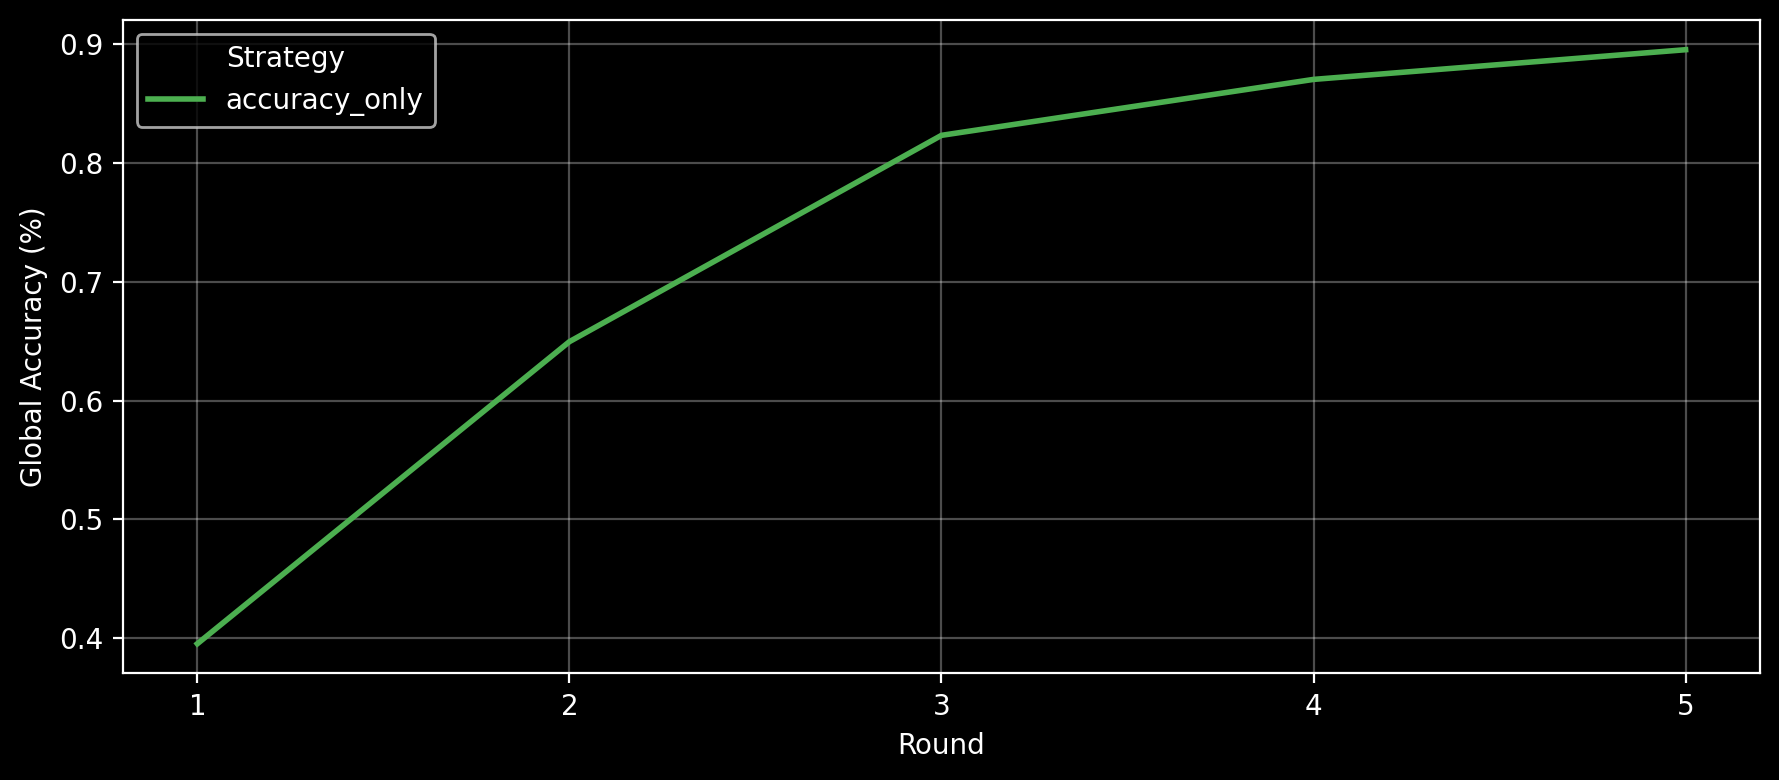

In [6]:
data = res['global']

# It logs self.pytorch_model.accuracy[-1] — so it's the accuracy of the global model evaluated after
# merging all participants' weights each round. That's the true global model performance, distinct from
# individual user accuracies.

# vals = grs_by_user(data)
# data[['round', 'global_accuracy']]
# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

# data

vals = global_acc_by_aggregation_strategy(data)
fig = plot_global_acc_by_aggregation_strategy(vals)

## Plot: Model Performance by Global Loss for aggregation strategies

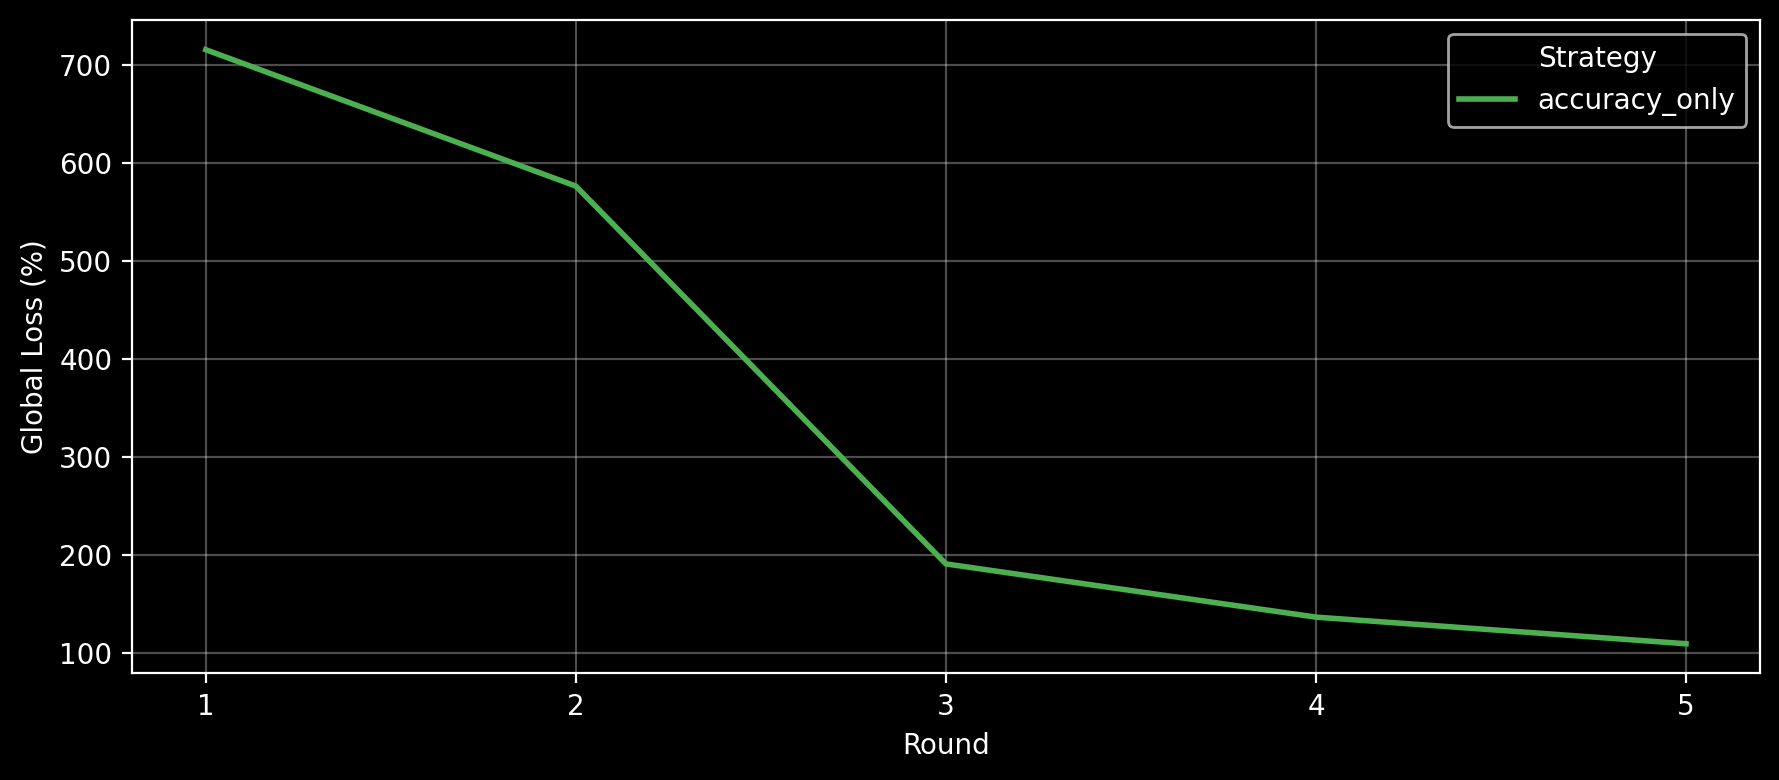

In [7]:
data = res['global']

# ●It logs self.pytorch_model.loss[-1] — so it's the loss of the global model evaluated after
#  merging all participants' weights each round. That's the true global model performance, distinct from
#  individual user accuracies.

# vals = grs_by_user(data)
# data[['round', 'global_loss']]
# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

# data

vals = global_loss_by_aggregation_strategy(data)
fig = plot_global_loss_by_aggregation_strategy(vals)

## Query: Runtime warnings

In [8]:
# data = res['setup'] does not work

data = res['warnings']
data

""
